# The 2nd Assignment

Implement one of the object detection methods to solve certain problem without using library. Give analysis of your results in term of accuracy and IoU.

Atha Putra Fausta

24/538657/PA/22864

## Sliding Window

In this notebook, sliding window will be used to find myself from a group photo. First, the group photo is imported. Then sliding window is used with template matching to find my face. Here, Normalized Cross-Correlation (NCC) similarity function is used because it compares patterns, not raw brightness, so the detection will still work in different exposure.

In [1]:
from PIL import Image
import numpy as np

# Load images

img = Image.open("./data/dikeminton.jpeg").convert("L")
template = Image.open("./data/face.jpeg").convert("L")

img_np = np.array(img)
tpl_np = np.array(template)

H, W = img_np.shape
h, w = tpl_np.shape

print(img_np.shape)
print(tpl_np.shape)

(2340, 4160)
(146, 140)


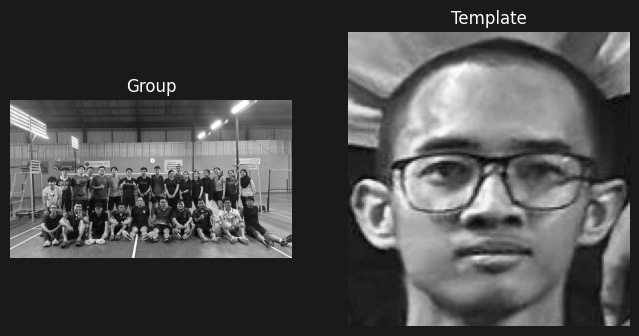

In [2]:
# Preview the images

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_np, cmap="gray")
plt.title("Group")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(tpl_np, cmap="gray")
plt.title("Template")
plt.axis("off")

plt.show()

In [3]:
def ncc(patch, template):
    patch = patch.astype(np.float32)
    template = template.astype(np.float32)

    patch = patch - patch.mean()
    template = template - template.mean()

    numerator = np.sum(patch * template)
    denominator = np.sqrt(np.sum(patch**2) * np.sum(template**2))

    if denominator < 1e-8:
        return 0.0

    return numerator / denominator

In [ ]:
# Sliding window

stride = 10

best_score = -1
best_box = None

for y in range(0, H - h, stride):
    for x in range(0, W - w, stride):

        patch = img_np[y:y+h, x:x+w]

        score = ncc(patch, tpl_np)

        if score > best_score:
            best_score = score
            best_box = (x, y, w, h)

print("Best score:", best_score)
print("Best box:", best_box)

In [ ]:
# Preview result

import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(img_np, cmap="gray")

if best_box is not None:
    x, y, w, h = best_box
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

    ax.set_title(f"Best match (score={best_score:.3f})")
else:
    ax.set_title("No match found")

plt.axis("off")
plt.show()

Here, the best match of the group photo with the template is 0.722. To check if the prediction is correct, Intersection over union evaluation will be used.

In [ ]:
# IoU Eval
def compute_iou(boxA, boxB):
    ax1, ay1, ax2, ay2 = boxA
    bx1, by1, bx2, by2 = boxB

    # intersection
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)

    inter_area = inter_w * inter_h

    # areas
    areaA = (ax2 - ax1) * (ay2 - ay1)
    areaB = (bx2 - bx1) * (by2 - by1)

    union = areaA + areaB - inter_area

    if union == 0:
        return 0

    return inter_area / union

In [ ]:
gt_box = (576, 1540, 716, 1680)

px1 = x
py1 = y
px2 = x + w
py2 = y + h

pred_box = (px1, py1, px2, py2)

iou = compute_iou(pred_box, gt_box)

print("IoU:", iou)

In [ ]:
import matplotlib.patches as patches

fig, ax = plt.subplots()
ax.imshow(img_np, cmap="gray")

# prediction (red)
rect_pred = patches.Rectangle(
    (px1, py1), px2-px1, py2-py1,
    linewidth=2, edgecolor='red', facecolor='none'
)

# ground truth (green)
rect_gt = patches.Rectangle(
    (gt_box[0], gt_box[1]),
    gt_box[2]-gt_box[0],
    gt_box[3]-gt_box[1],
    linewidth=2, edgecolor='green', facecolor='none'
)

ax.add_patch(rect_pred)
ax.add_patch(rect_gt)

plt.title(f"IoU = {iou:.3f}")
plt.axis("off")
plt.show()

After evaluating the result, 0.907 IoU is obtained, showing that the prediction is very close to the ground truth, meaning that the sliding window is able to find my face from the group photo.